<a href="https://colab.research.google.com/github/rohan604037/ML-lab/blob/main/lab10/10b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Confusion Matrix:
 [[14  0  0]
 [ 1 15  0]
 [ 0  0  6]]


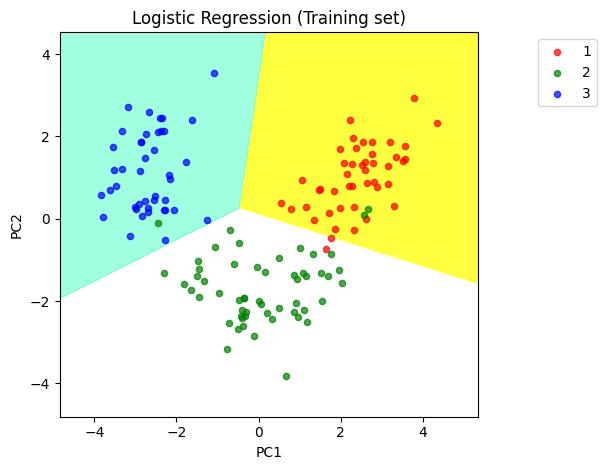

In [7]:
# Importing required libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Loading dataset
dataset = pd.read_csv('wine.csv')

# Features (X) and target (y)
# Correcting X to be all columns except the first (class label)
# Correcting y to be the first column (class label)
X = dataset.iloc[:, 1:].values
y = dataset.iloc[:, 0].values

# Splitting into Training and Testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Applying PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

explained_variance = pca.explained_variance_ratio_

# Logistic Regression
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state=0)
classifier.fit(X_train, y_train)

# Predicting test results
y_pred = classifier.predict(X_test)

# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Visualization (Training set)
from matplotlib.colors import ListedColormap

X_set, y_set = X_train, y_train

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min()-1, stop=X_set[:, 0].max()+1, step=0.01),
    np.arange(start=X_set[:, 1].min()-1, stop=X_set[:, 1].max()+1, step=0.01)
)

plt.contourf(
    X1, X2,
    classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75,
    cmap=ListedColormap(('yellow', 'white', 'aquamarine'))
)

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        color=ListedColormap(('red', 'green', 'blue'))(i), # Changed 'c' to 'color'
        label=j,
        s=20,
        alpha=0.7
    )

plt.title('Logistic Regression (Training set)')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
plt.tight_layout()

plt.show()